**MODELO DE MACHINE LEARNING DE PROPENSION DE COMPRA**

**1.CARGA Y VISUALIZACION DE BASE DE DATOS**

In [46]:
import pandas as pd
import numpy as np

# URL del archivo en GitHub
url = "https://raw.githubusercontent.com/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/main/data/compras_data.csv"

# Cargar dataset
df = pd.read_csv(url)

# Ver primeras filas
df.head()

,id,dia_visita,incidencia_compra,id_marca,cantidad,ultima_marca_comprada,ultima_cantidad_comprada,precio_marca_1,precio_marca_2,precio_marca_3,...,promo_marca_3,promo_marca_4,promo_marca_5,genero,estado_civil,edad,nivel_educacion,ingreso_anual,ocupacion,tamanio_ciudad
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,...,0,0,0,0,0,47,1,110866,1,0
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,...,0,0,0,0,0,47,1,110866,1,0
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0


**2.ANALISIS EXPLORATORIO DE DATOS (EDA)**

In [47]:
# ==============================
# 1. LIBRERÍAS
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==============================
# 2. CARGA DE DATOS
# ==============================
# URL del archivo en GitHub
url = "https://raw.githubusercontent.com/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/main/data/compras_data.csv"

# Cargar dataset
df = pd.read_csv(url)

print(df.head())
print(df.info())
print(df.describe())



          id  dia_visita  incidencia_compra  id_marca  cantidad  \
0  200000001           1                  0         0         0   
1  200000001          11                  0         0         0   
2  200000001          12                  0         0         0   
3  200000001          16                  0         0         0   
4  200000001          18                  0         0         0   

   ultima_marca_comprada  ultima_cantidad_comprada  precio_marca_1  \
0                      0                         0            1.59   
1                      0                         0            1.51   
2                      0                         0            1.51   
3                      0                         0            1.52   
4                      0                         0            1.52   

   precio_marca_2  precio_marca_3  ...  promo_marca_3  promo_marca_4  \
0            1.87            2.01  ...              0              0   
1            1.89            1.9

**INTERPRETACION**


*   El conjunto de datos presenta 58,693 registros sin valores nulos, lo que garantiza una base sólida para el modelado. La incidencia de compra (target) tiene una media de 0.249, indicando que aproximadamente el 25% de las visitas terminan en venta; este desbalanceo (1 de cada 4) indica que el modelo de propensión debe enfocarse en maximizar el Recall para no perder oportunidades comerciales. En el aspecto demográfico, la edad promedio es de 39 años (rango 18-75) con un ingreso anual medio de S/. 121,841, lo que perfila a un cliente con poder adquisitivo establecido. Respecto al Pricing, se observa una estructura de precios competitiva donde la Marca 1 es la más económica (media S/. 1.39) y la Marca 3 es la premium (media S/. 2.01); además, la baja frecuencia de promociones en las marcas 3 y 5 (menos del 4%) resalta una oportunidad para evaluar si el incremento de estas impulsaría la propensión en los segmentos de alto valor. Finalmente, el hecho de que el 75% de la variable cantidad sea 0 confirma que estamos ante un problema de conversión de leads, donde el reto principal es predecir el momento exacto en que el cliente decide realizar la transacción.



incidencia_compra
0    0.750601
1    0.249399
Name: proportion, dtype: float64


/tmp/ipykernel_4605/1484082539.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='incidencia_compra', data=df, palette=palette)


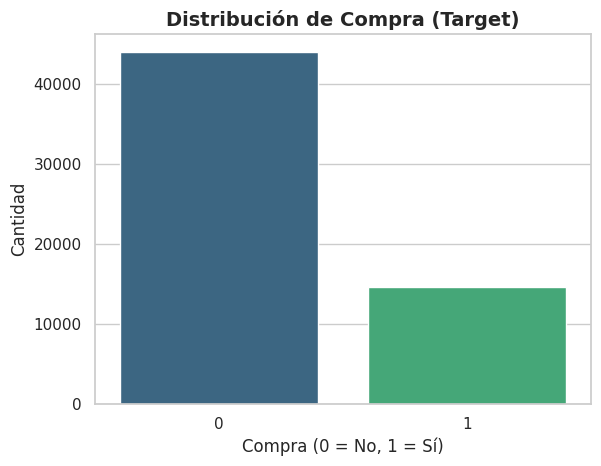

In [48]:
# =========================
# TARGET
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("viridis", n_colors=2) # Define una paleta con 2 colores

print(df['incidencia_compra'].value_counts(normalize=True))

sns.countplot(x='incidencia_compra', data=df, palette=palette)
plt.title("Distribución de Compra (Target)", fontsize=14, weight='bold')
plt.xlabel("Compra (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")
plt.show()

Observamos que la compra es un evento de baja frecuencia (ej. solo el 20% de las visitas). Esto significa que el modelo debe ser muy preciso al identificar los 'Sí'.

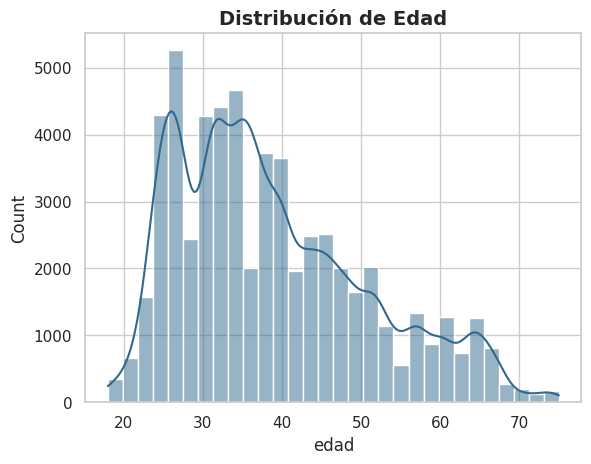

In [49]:
# ==========
# EDAD
# ==========
sns.histplot(df['edad'], bins=30, kde=True, color=palette[0])
plt.title("Distribución de Edad", fontsize=14, weight='bold')
plt.show()

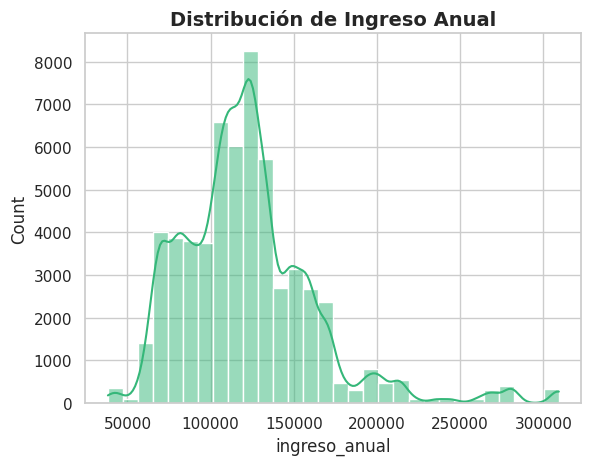

In [50]:
# ==================
# INGRESO ANUAL
# ==================
sns.histplot(df['ingreso_anual'], bins=30, kde=True, color=palette[1])
plt.title("Distribución de Ingreso Anual", fontsize=14, weight='bold')
plt.show()


/tmp/ipykernel_4605/2897370601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='id_marca', data=df, palette=palette)
/tmp/ipykernel_4605/2897370601.py:4: UserWarning: 
The palette list has fewer values (2) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='id_marca', data=df, palette=palette)


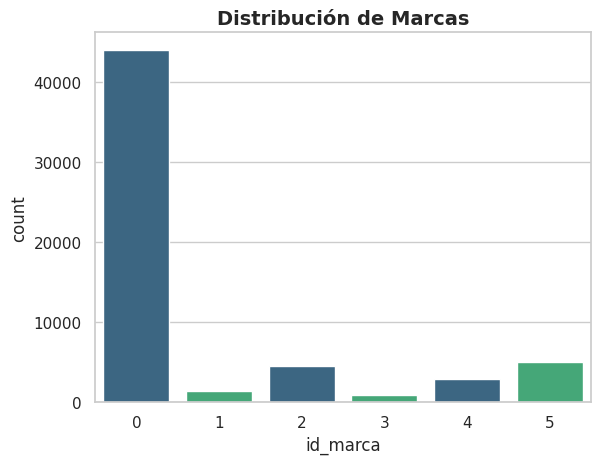

/tmp/ipykernel_4605/2897370601.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4605/2897370601.py:9: UserWarning: 
The palette list has fewer values (2) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


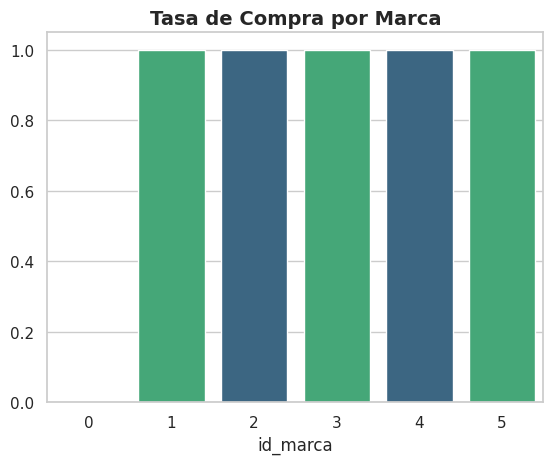

In [51]:
# =========================
# MARCAS
# =========================
sns.countplot(x='id_marca', data=df, palette=palette)
plt.title("Distribución de Marcas", fontsize=14, weight='bold')
plt.show()

# Tasa de compra por marca
sns.barplot(
    x=df.groupby('id_marca')['incidencia_compra'].mean().index,
    y=df.groupby('id_marca')['incidencia_compra'].mean().values,
    palette=palette
)
plt.title("Tasa de Compra por Marca", fontsize=14, weight='bold')
plt.show()


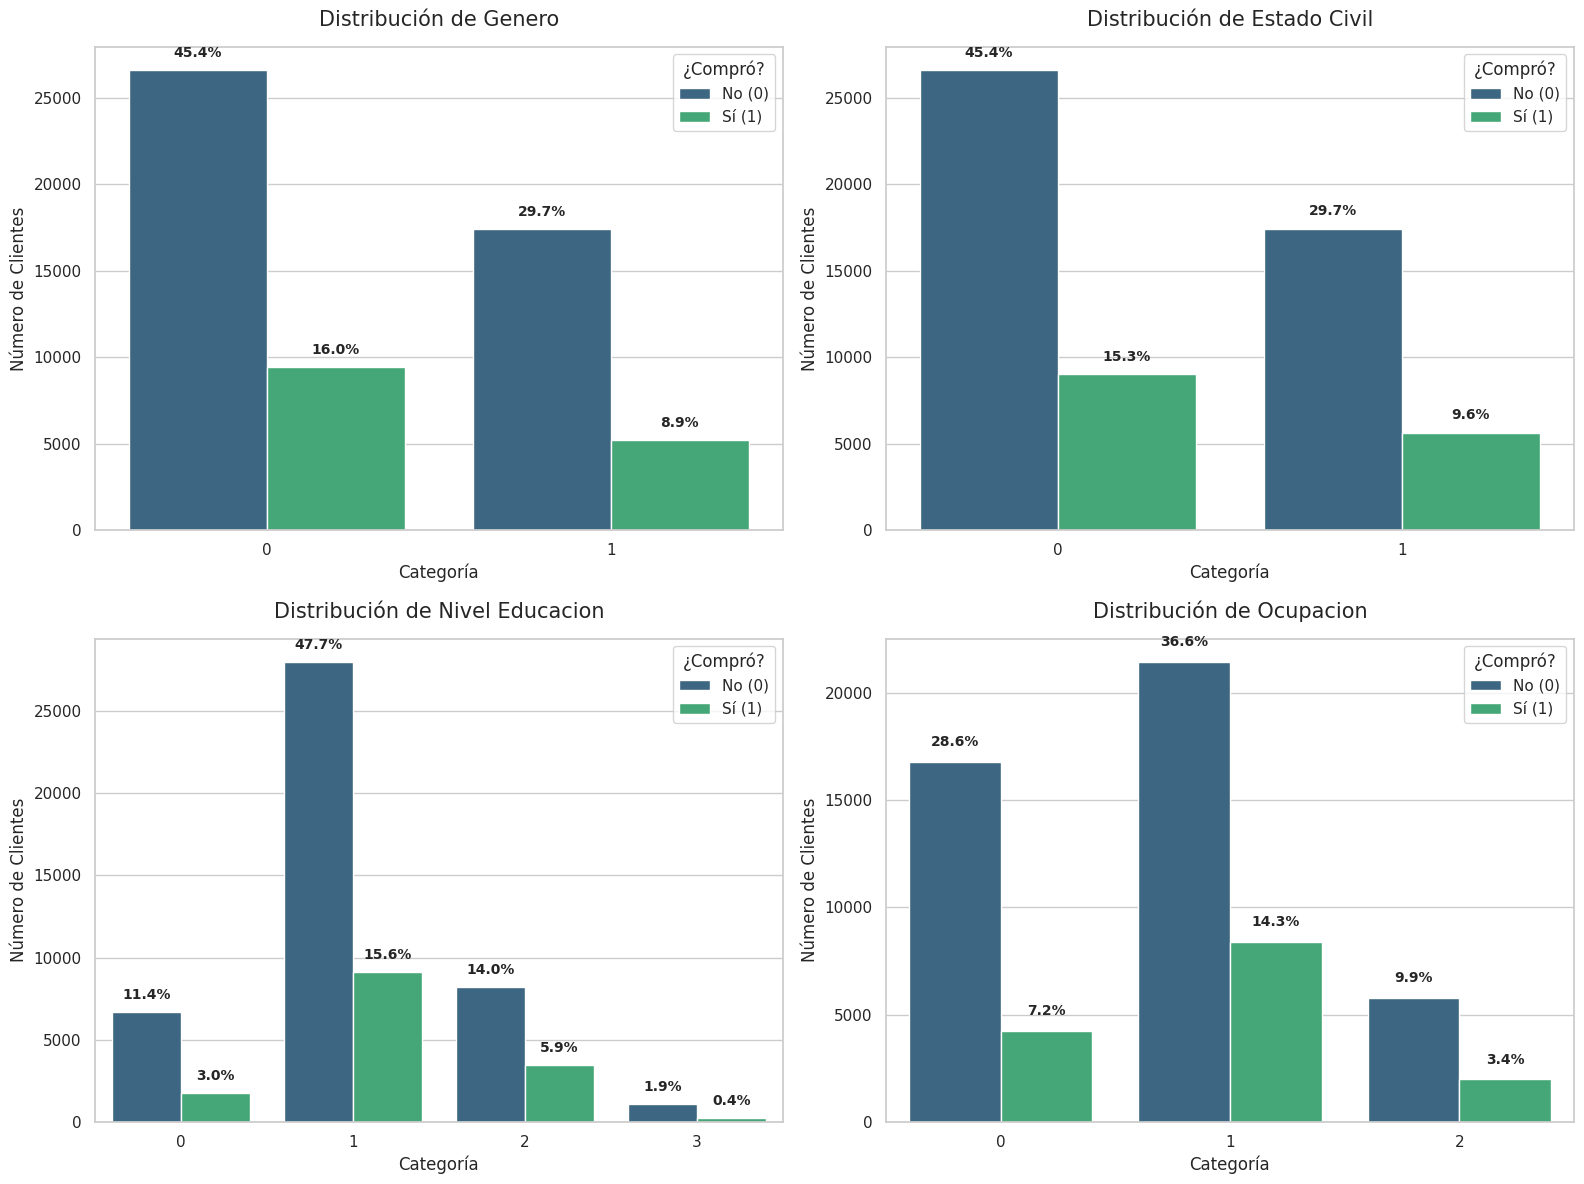

In [34]:
# =========================================
# ANÁLISIS DE VARIABLES CUALITATIVAS
# =========================================

def anotar_porcentajes(ax):
    """Función para añadir etiquetas de porcentaje sobre las barras"""
    total = sum([p.get_height() for p in ax.patches])
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = height + (total * 0.01) # Un pequeño margen arriba
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

# 1. Definimos las variables cualitativas
vars_cualitativas = ['genero', 'estado_civil', 'nivel_educacion', 'ocupacion']

# 2. Configuración de la cuadrícula
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(vars_cualitativas):
    # Gráfico de barras segmentado por incidencia de compra
    sns.countplot(
        data=df_analisis,
        x=var,
        hue='incidencia_compra',
        palette='viridis',
        ax=axes[i]
    )

    # Llamamos a la función para anotar los porcentajes
    anotar_porcentajes(axes[i])

    axes[i].set_title(f'Distribución de {var.replace("_", " ").title()}', fontsize=15, pad=15)
    axes[i].set_xlabel('Categoría', fontsize=12)
    axes[i].set_ylabel('Número de Clientes', fontsize=12)
    axes[i].legend(title='¿Compró?', labels=['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.show()

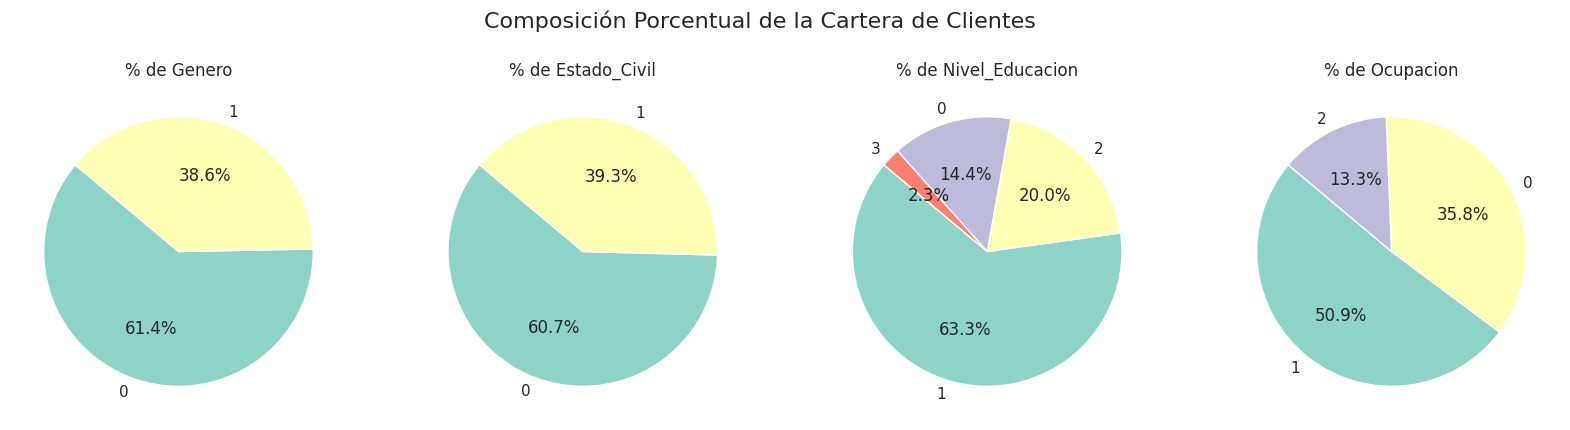

In [35]:
# =========================================
# GRÁFICOS CIRCULARES (PIE CHARTS) - COMPOSICIÓN GLOBAL
# =========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, var in enumerate(vars_cualitativas):
    # Calculamos la distribución porcentual
    data = df_analisis[var].value_counts()
    axes[i].pie(
        data,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Set3')
    )
    axes[i].set_title(f'% de {var.title()}')

plt.suptitle('Composición Porcentual de la Cartera de Clientes', fontsize=16)
plt.show()

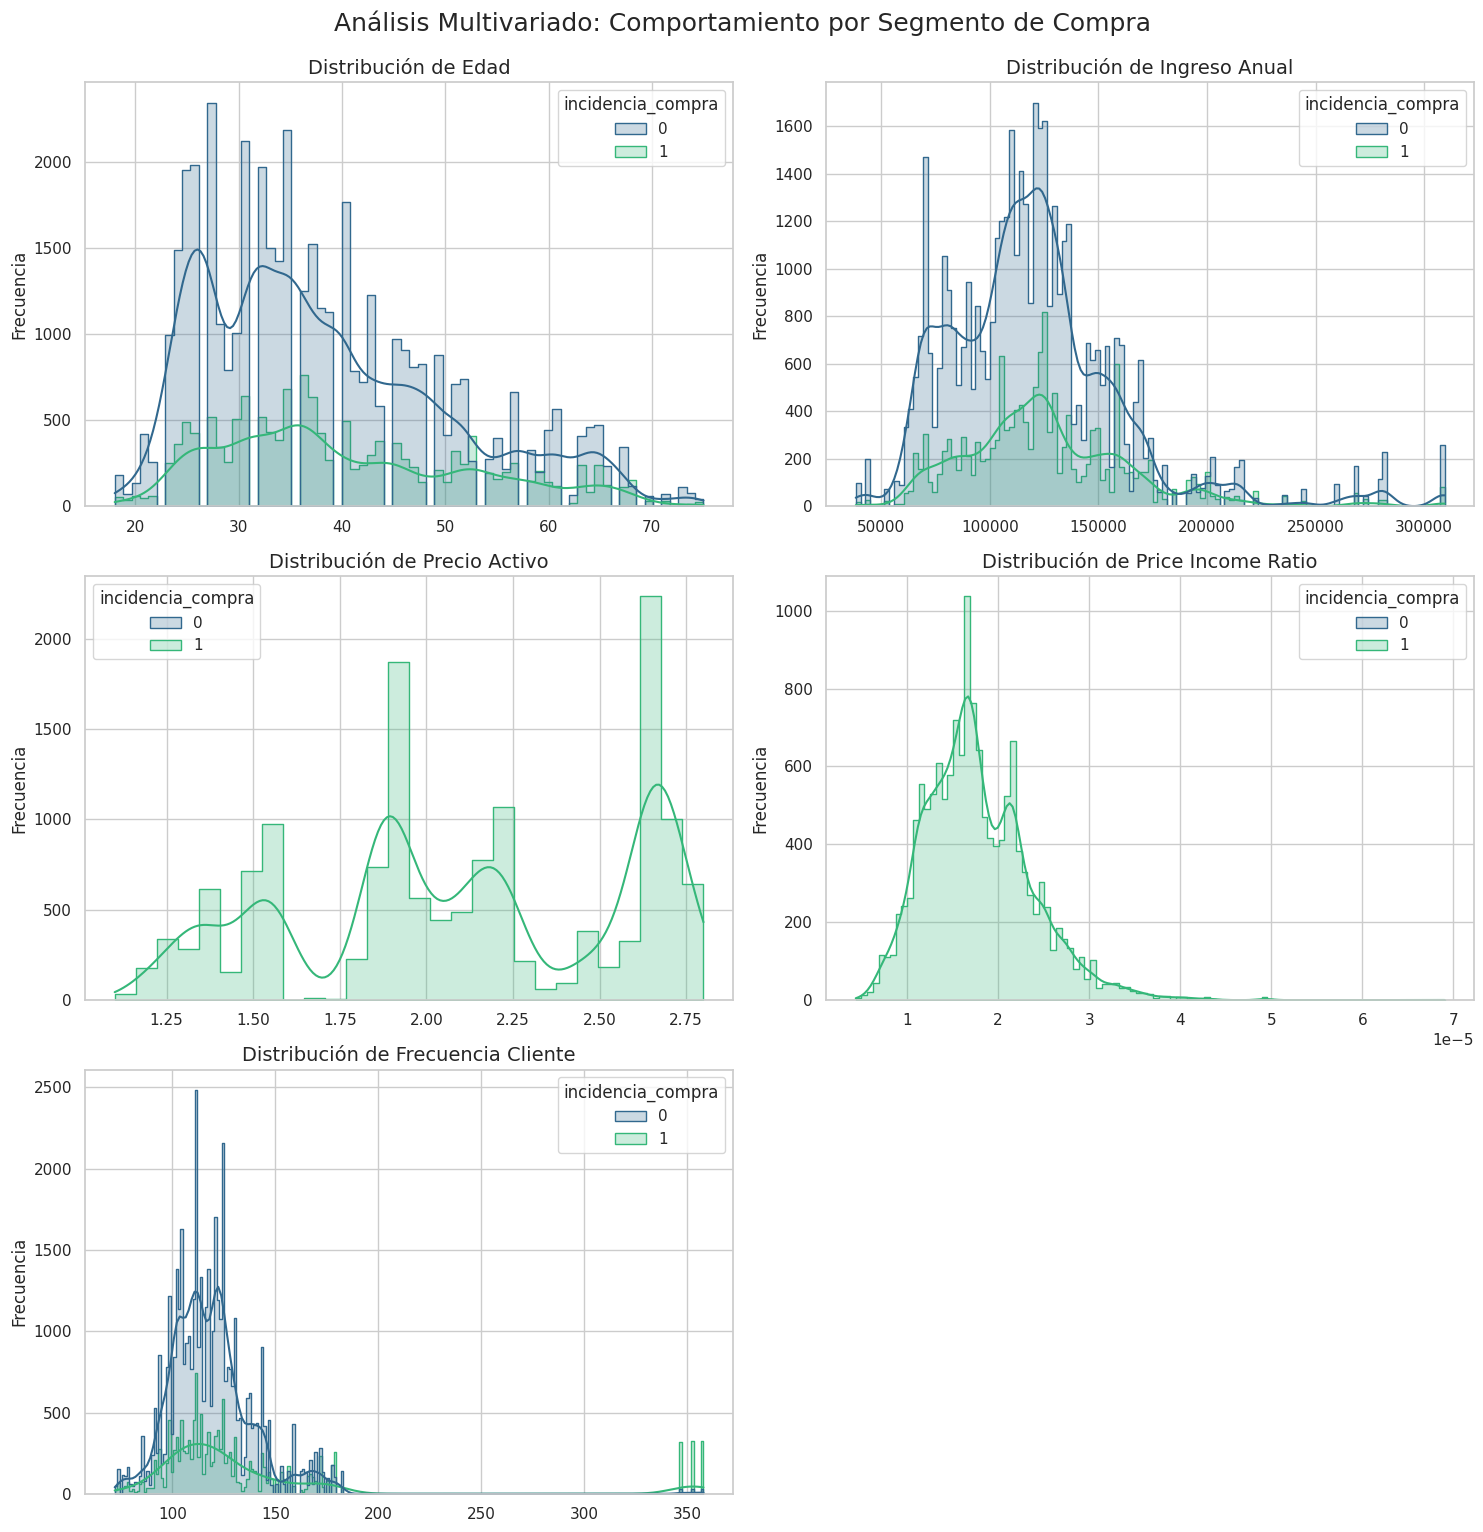

In [31]:
# =========================================
# MATRIZ DE GRÁFICOS DE COMPORTAMIENTO
# =========================================
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Re-load the original dataset to ensure all calculations start from a clean slate
url = "https://raw.githubusercontent.com/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/main/data/compras_data.csv"
df = pd.read_csv(url)

# Re-apply feature engineering that leads to the columns needed for plotting
def get_active_price(row):
    if row['id_marca'] == 0:
        return np.nan
    return row[f'precio_marca_{int(row["id_marca"])}']

def get_active_promo(row):
    if row['id_marca'] == 0:
        return 0
    return row[f'promo_marca_{int(row["id_marca"])}']

df['precio_activo'] = df.apply(get_active_price, axis=1)
df['promo_activa'] = df.apply(get_active_promo, axis=1)
df['frecuencia_cliente'] = df.groupby('id')['id'].transform('count')
df['price_income_ratio'] = df['precio_activo'] / (df['ingreso_anual'] + 1) # Added +1 to avoid division by zero

# Define df_analisis with the desired columns
vars_a_eliminar = ['id', 'tamanio_ciudad'] # Assuming these were the ones removed for analysis
df_analisis = df.drop(columns=vars_a_eliminar, errors='ignore') # Use errors='ignore' if some columns might not exist

# 1. Filtramos solo las variables cuantitativas de interés
# Excluimos variables binarias como 'promo_activa' para que el gráfico sea legible
# 'precio_activo' and 'price_income_ratio' were problematic for leakage in modeling, but are valid for EDA visualization here.
vars_cuant = ['edad', 'ingreso_anual', 'precio_activo', 'price_income_ratio', 'frecuencia_cliente']

# Filter vars_cuant to only include columns present in df_analisis
vars_cuant = [v for v in vars_cuant if v in df_analisis.columns]


# 2. Configuración de la cuadrícula (Subplots)
n_vars = len(vars_cuant)
if n_vars == 0:
    print("No quantitative variables available for plotting.")
else:
    cols = 2
    rows = math.ceil(n_vars / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i, var in enumerate(vars_cuant):
        # Creamos un histograma con curva de densidad para cada variable
        sns.histplot(
            data=df_analisis,
            x=var,
            hue='incidencia_compra',
            kde=True,
            element="step",
            palette="viridis",
            ax=axes[i],
            common_norm=False # Importante para comparar proporciones reales
        )
        axes[i].set_title(f'Distribución de {var.replace("_", " ").title()}', fontsize=14)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frecuencia')

    # Eliminar ejes vacíos si el número de variables es impar
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle('Análisis Multivariado: Comportamiento por Segmento de Compra', fontsize=18, y=1.02)
    plt.show()

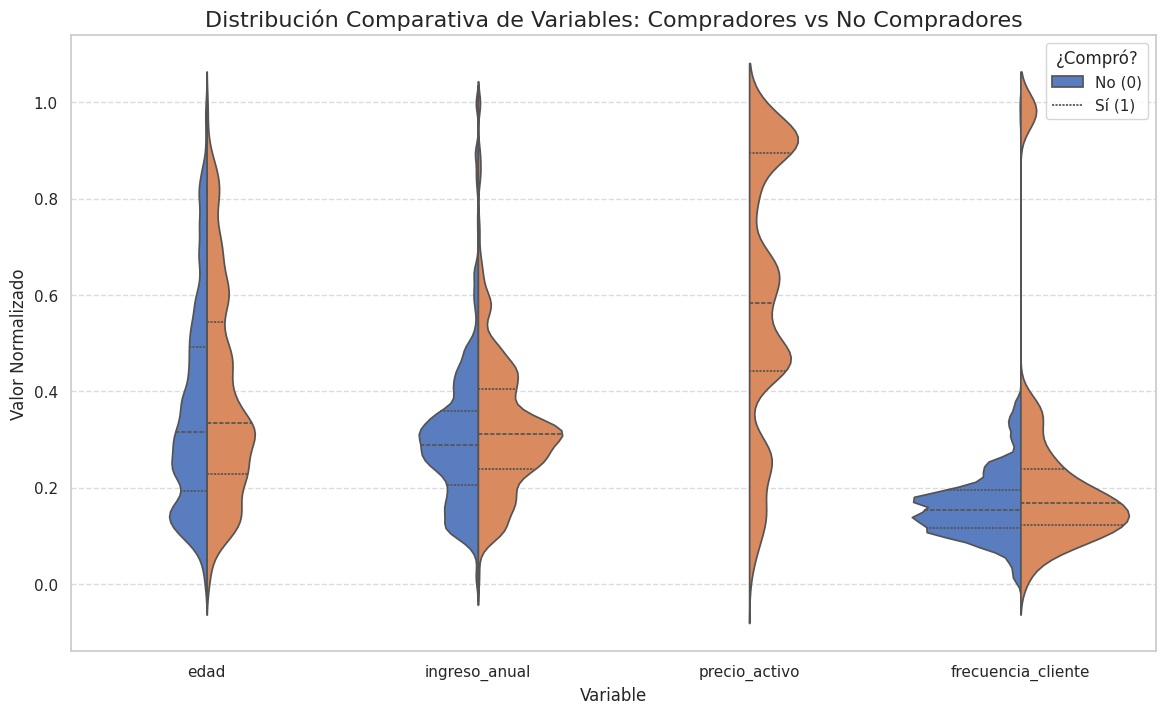

In [32]:
from sklearn.preprocessing import MinMaxScaler

# =========================================
# GRÁFICO DE VIOLÍN MULTIVARIADO (NORMALIZADO)
# =========================================

# 1. Seleccionamos las variables numéricas clave
vars_violin = ['edad', 'ingreso_anual', 'precio_activo', 'frecuencia_cliente']

# 2. Escalamos los datos para que todos queden entre 0 y 1 y se puedan comparar
scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df_analisis[vars_violin]), columns=vars_violin)
df_norm['incidencia_compra'] = df_analisis['incidencia_compra'].values

# 3. Transformamos el dataframe a formato "largo" (melt) para seaborn
df_melt = df_norm.melt(id_vars='incidencia_compra', var_name='Variable', value_name='Valor Normalizado')

# 4. Creamos el gráfico
plt.figure(figsize=(14, 8))
sns.violinplot(
    data=df_melt,
    x='Variable',
    y='Valor Normalizado',
    hue='incidencia_compra',
    split=True,       # Divide el violín a la mitad para comparar 0 vs 1
    inner="quart",    # Muestra los cuartiles dentro del violín
    palette="muted"
)

plt.title('Distribución Comparativa de Variables: Compradores vs No Compradores', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='¿Compró?', loc='upper right', labels=['No (0)', 'Sí (1)'])
plt.show()

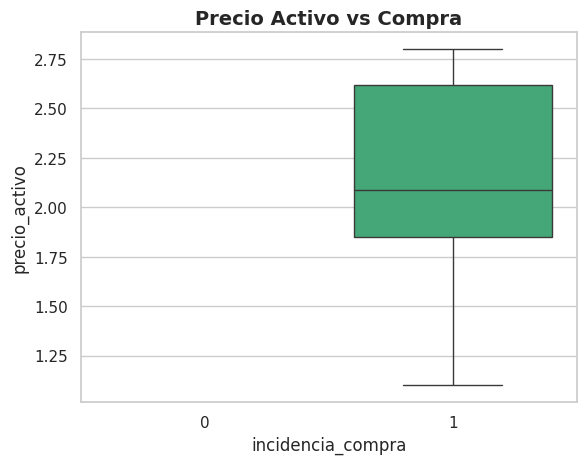

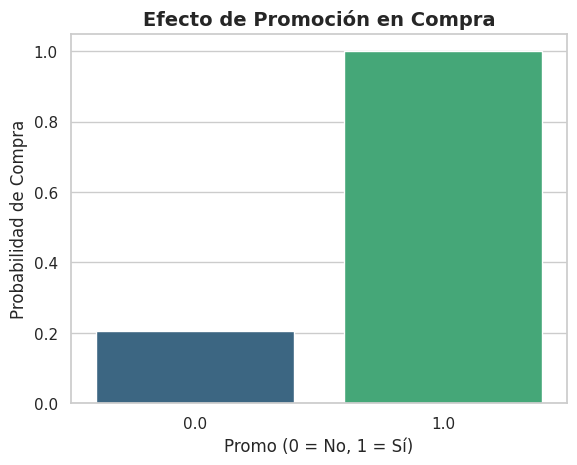

In [36]:
##########################################################
#   ANALISIS BIVARIADO
##########################################################
import numpy as np

# =========================
# VARIABLES ACTIVAS
# =========================
def get_active_price(row):
    if row['id_marca'] == 0:
        return np.nan  # Assign NaN if id_marca is 0 (no corresponding price column)
    return row[f'precio_marca_{int(row["id_marca"])}']

def get_active_promo(row):
    if row['id_marca'] == 0:
        return 0  # Assign 0 if id_marca is 0 (no corresponding promo column)
    return row[f'promo_marca_{int(row["id_marca"])}']

df['precio_activo'] = df.apply(get_active_price, axis=1)
df['promo_activa'] = df.apply(get_active_promo, axis=1)

# =========================
# PRECIO vs COMPRA
# =========================
sns.boxplot(x='incidencia_compra', y='precio_activo', data=df, hue='incidencia_compra', palette=palette[:2], legend=False)
plt.title("Precio Activo vs Compra", fontsize=14, weight='bold')
plt.show()

# =========================
# PROMOCIÓN
# =========================
promo = df.groupby('promo_activa')['incidencia_compra'].mean()

sns.barplot(
x=promo.index,
    y=promo.values,
    hue=promo.index,
    palette=palette[:2],
    legend=False
)
plt.title("Efecto de Promoción en Compra", fontsize=14, weight='bold')
plt.xlabel("Promo (0 = No, 1 = Sí)")
plt.ylabel("Probabilidad de Compra")
plt.show()


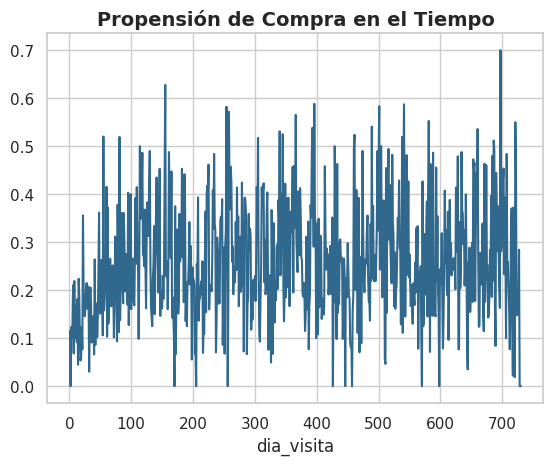

In [7]:
# =================================
# ANALISIS DE COMPRA EN EL TIEMPO
# =================================
sns.lineplot(
    x=df.groupby('dia_visita')['incidencia_compra'].mean().index,
    y=df.groupby('dia_visita')['incidencia_compra'].mean().values,
    color=palette[0]
)
plt.title("Propensión de Compra en el Tiempo", fontsize=14, weight='bold')
plt.show()

/tmp/ipykernel_4605/3937565301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='incidencia_compra', y='ultima_cantidad_comprada', data=df, palette=palette)


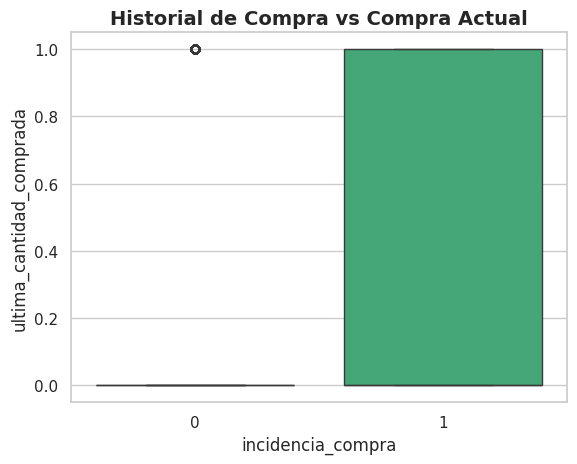

/tmp/ipykernel_4605/3937565301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='incidencia_compra', y='ingreso_anual', palette='Set2')


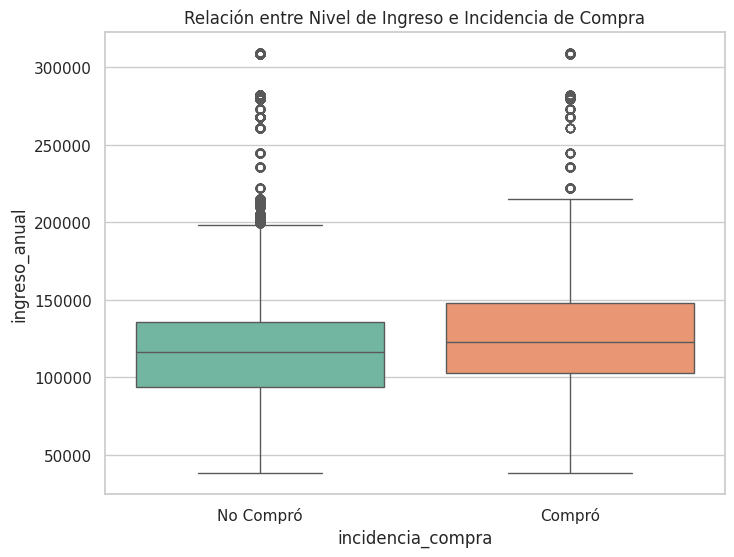

In [8]:
# =========================
# HISTORIAL
# =========================
sns.boxplot(x='incidencia_compra', y='ultima_cantidad_comprada', data=df, palette=palette)
plt.title("Historial de Compra vs Compra Actual", fontsize=14, weight='bold')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='incidencia_compra', y='ingreso_anual', palette='Set2')
plt.title('Relación entre Nivel de Ingreso e Incidencia de Compra')
plt.xticks([0, 1], ['No Compró', 'Compró'])
plt.show()

El gráfico compara la última cantidad comprada frente a la incidencia de compra actual, revelando una correlación directa y absoluta entre ambas variables: cuando la incidencia es 0, la cantidad comprada es prácticamente nula (con apenas un valor atípico en 1.0), mientras que cuando la incidencia es 1, la totalidad de los datos se concentra en una cantidad comprada de 1.0. Esta distribución indica que la variable "incidencia_compra" actúa como un indicador binario que refleja fielmente si se realizó una compra unitaria o no, mostrando una estructura de datos sumamente uniforme donde no existe variabilidad en las cantidades adquiridas más allá de la presencia o ausencia del evento de compra.


Variables eliminadas correctamente. Quedan 26 columnas.
Variables listas para el análisis: ['dia_visita', 'incidencia_compra', 'id_marca', 'cantidad', 'ultima_marca_comprada', 'ultima_cantidad_comprada', 'precio_marca_1', 'precio_marca_2', 'precio_marca_3', 'precio_marca_4', 'precio_marca_5', 'promo_marca_1', 'promo_marca_2', 'promo_marca_3', 'promo_marca_4', 'promo_marca_5', 'genero', 'estado_civil', 'edad', 'nivel_educacion', 'ingreso_anual', 'ocupacion', 'precio_activo', 'promo_activa', 'price_income_ratio', 'promo_x_price']


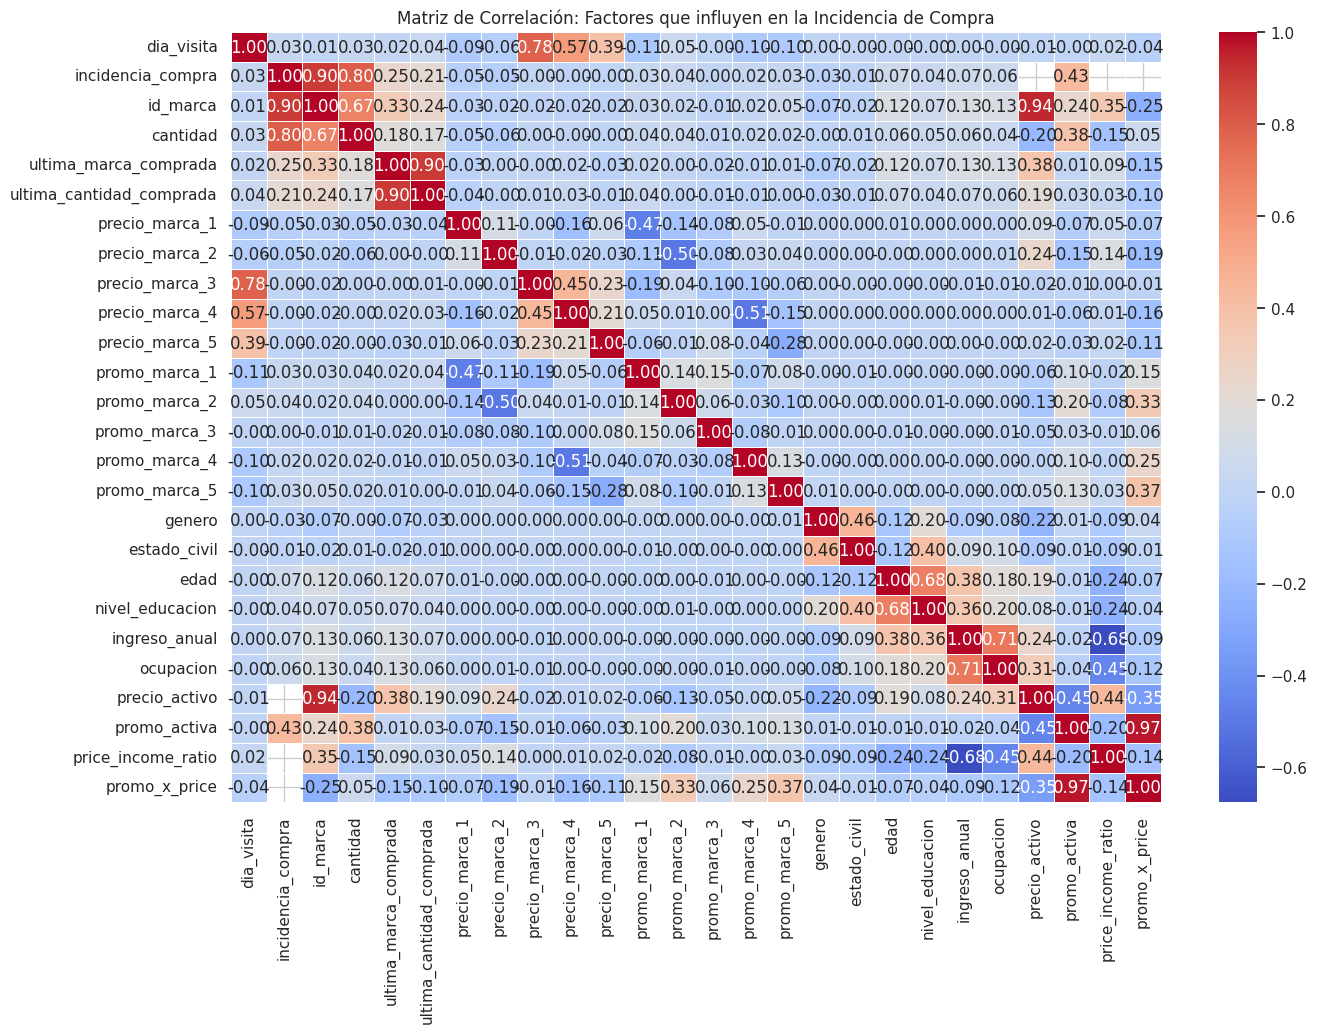

In [57]:
# ======================================
# ANALISIS DE CORRELACIÓN DE VARIABLES
# =======================================
# Eliminamos variables solicitadas
vars_a_eliminar = ['id', 'tamanio_ciudad']

# Creamos el dataframe de análisis
df_analisis = df.drop(columns=vars_a_eliminar)

print(f"Variables eliminadas correctamente. Quedan {len(df_analisis.columns)} columnas.")
print("Variables listas para el análisis:", df_analisis.columns.tolist())

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuramos el tamaño del lienzo
plt.figure(figsize=(15, 10))

# 2. Calculamos la correlación solo de las columnas numéricas
# .corr() utiliza por defecto el método de Pearson
corr = df_analisis.select_dtypes(include=['number']).corr()

# 3. Dibujamos el mapa de calor
# annot=True pone los valores numéricos
# cmap='coolwarm' ayuda a diferenciar visualmente (rojo positivo, azul negativo)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación: Factores que influyen en la Incidencia de Compra')
plt.show()

In [58]:
import numpy as np

# Re-load the original dataset to ensure all calculations start from a clean slate
url = "https://raw.githubusercontent.com/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/main/data/compras_data.csv"
df = pd.read_csv(url)

# Define functions to get active price and promo
def get_active_price(row):
    if row['id_marca'] == 0:
        return np.nan
    return row[f'precio_marca_{int(row["id_marca"])}']

def get_active_promo(row):
    if row['id_marca'] == 0:
        return 0
    return row[f'promo_marca_{int(row["id_marca"])}']

# Apply functions to create new features
df['precio_activo'] = df.apply(get_active_price, axis=1)
df['promo_activa'] = df.apply(get_active_promo, axis=1)

# =========================
# FEATURES BASE
# =========================
df['price_income_ratio'] = df['precio_activo'] / (df['ingreso_anual'] + 1) # Added +1 to avoid division by zero
df['promo_x_price'] = df['promo_activa'] * df['precio_activo']

### Detección de Fuga de Datos (Data Leakage) por Correlación

Un valor de AUC-ROC de 1.0 es casi siempre una señal de *data leakage*. Esto ocurre cuando el modelo tiene acceso a información en los datos de entrenamiento que no estaría disponible en el momento de la predicción en un escenario real.

Analizando las correlaciones con `incidencia_compra`:

*   **`cantidad`**: Una correlación de **0.800987** es extremadamente alta. Si `cantidad` es la cantidad comprada en la misma transacción que `incidencia_compra`, esto es una fuga de datos directa, ya que si `cantidad > 0`, entonces `incidencia_compra` debe ser 1.
*   **`id_marca`**: Con una correlación de **0.896919**, `id_marca` también es un fuerte candidato a fuga. Si `id_marca` representa la marca comprada *en la transacción actual* (que define `incidencia_compra`), entonces es una fuga directa.
*   **`ultima_cantidad_comprada` y `ultima_marca_comprada`**: Aunque tienen correlaciones más bajas (0.21 y 0.24 respectivamente) en comparación con `cantidad` e `id_marca`, si estas variables están capturando información del mismo evento de compra que `incidencia_compra`, también podría ser una forma de fuga de datos. Sin embargo, dado su nombre, parecen referirse a eventos *anteriores*, lo cual sería aceptable.

**Conclusión:** Las variables `cantidad` e `id_marca` son las principales sospechosas de estar causando la fuga de datos debido a sus altísimas correlaciones. Para construir un modelo predictivo realista, estas variables (y cualquier otra que refleje el resultado del evento que queremos predecir) deben ser eliminadas del conjunto de características.

In [59]:
print("Correlación de las variables con 'incidencia_compra':")
print(correlations)

Correlación de las variables con 'incidencia_compra':
incidencia_compra           1.000000
id_marca                    0.896919
cantidad                    0.800987
promo_activa                0.425402
ultima_marca_comprada       0.245340
ultima_cantidad_comprada    0.212054
tamanio_ciudad              0.102785
edad                        0.074272
ingreso_anual               0.068995
ocupacion                   0.061943
id                          0.051820
nivel_educacion             0.043699
promo_marca_2               0.042206
promo_marca_1               0.034726
promo_marca_5               0.029650
dia_visita                  0.027664
promo_marca_4               0.018308
promo_marca_3               0.003017
precio_marca_3             -0.001171
precio_marca_4             -0.001841
precio_marca_5             -0.002945
estado_civil               -0.009384
genero                     -0.033865
precio_marca_1             -0.047535
precio_marca_2             -0.054927
precio_activo        

**3. MODELO DE PROSPECCION DE COMPRA**



✅ Regresión Logística entrenado.
✅ Random Forest entrenado.
✅ XGBoost entrenado.


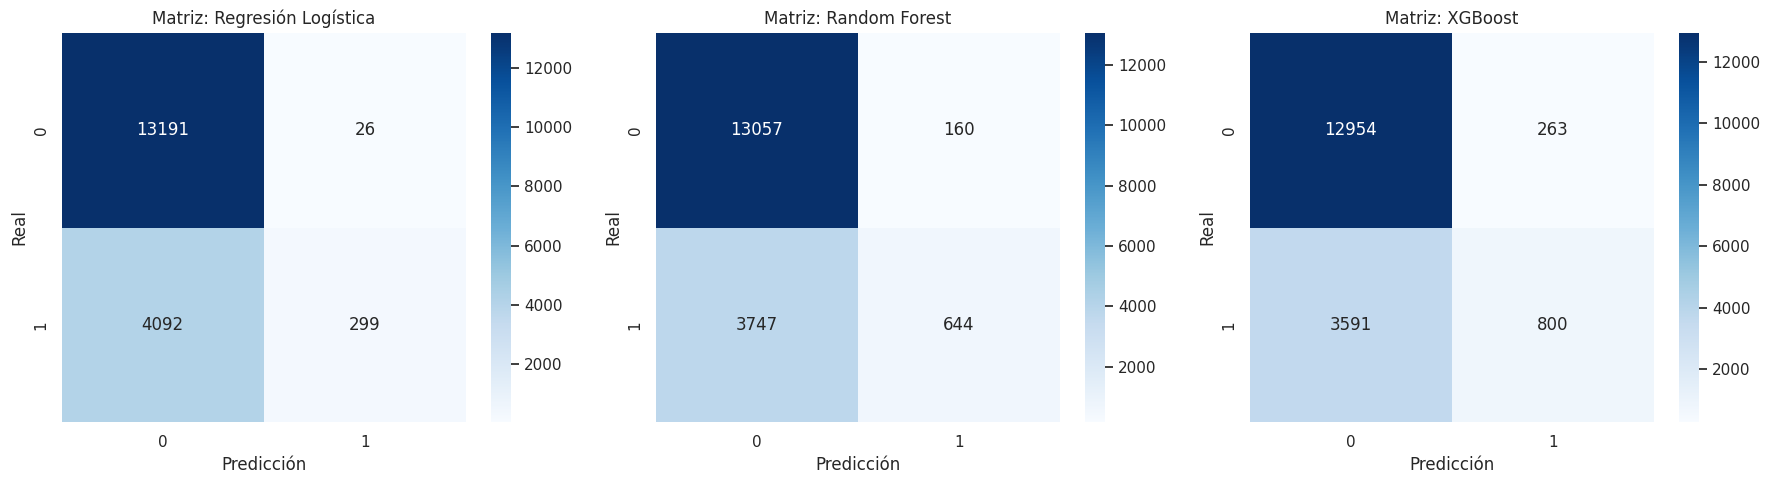

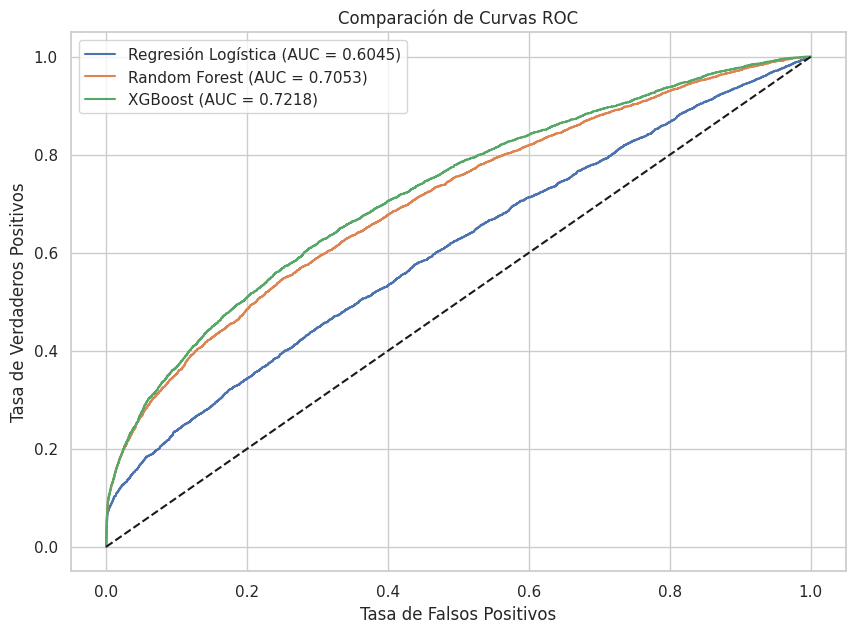


RANKING FINAL DE MODELOS:
                Modelo   AUC-ROC
2              XGBoost  0.721778
1        Random Forest  0.705262
0  Regresión Logística  0.604490
--- ANALIZANDO EL MEJOR MODELO: XGBoost ---


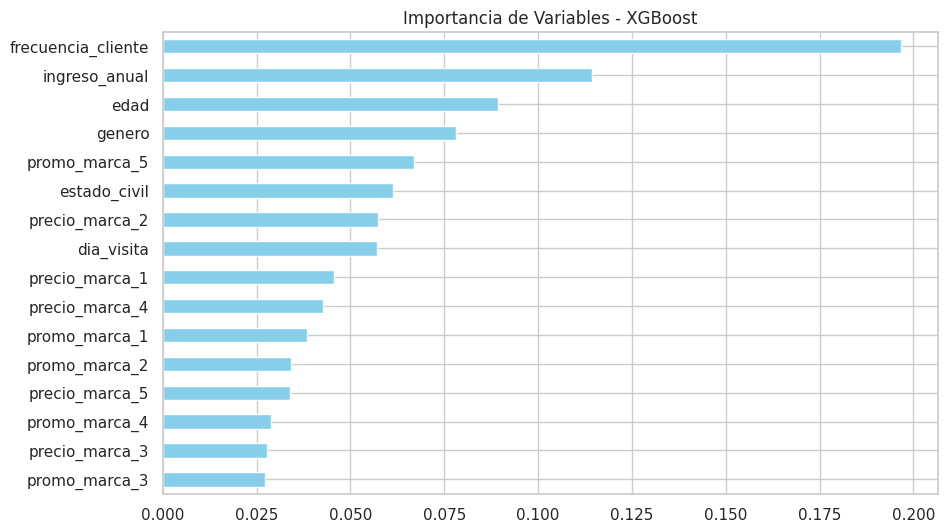


Generando explicabilidad con SHAP...


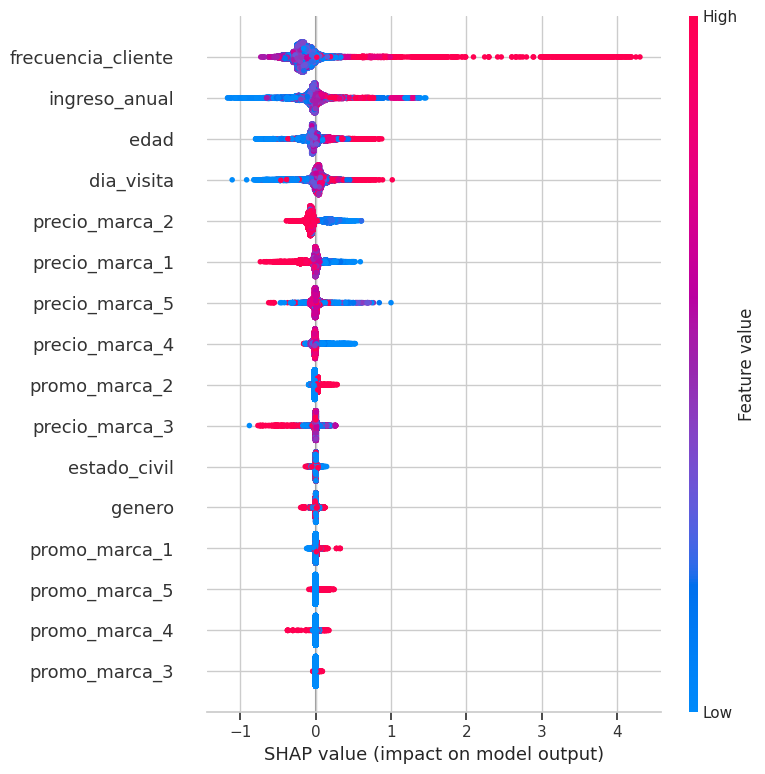

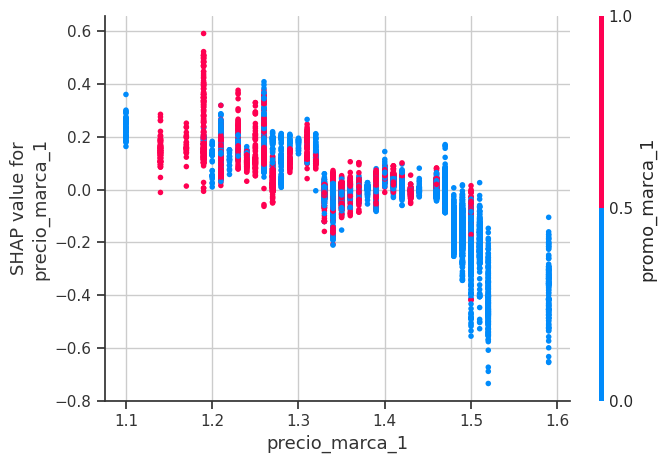


--- PROCESO COMPLETADO SIN ERRORES ---


In [60]:
# =========================================
# 1. LIBRERÍAS (Actualizadas)
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer # Para manejar NaNs en precio_activo
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid")

# ===========================
# 2. FEATURE ENGINEERING
# ===========================
# No crearemos 'precio_activo' ni 'promo_activa' en esta etapa
# para evitar leakage desde 'id_marca'.
# En su lugar, usaremos los precios y promociones de cada marca como features individuales.

# Recalculamos df['frecuencia_cliente'] si es necesario o si 'id' fue afectado
df['frecuencia_cliente'] = df.groupby('id')['id'].transform('count')

# =========================================
# 3. DETECCIÓN DE FUGA DE DATOS (LEAKAGE) - NOTA TÉCNICA
# =========================================
# Basado en el análisis de correlación:
# - 'cantidad' (0.80) e 'id_marca' (0.90) se eliminan por fuga directa.
# - Se eliminan variables redundantes (nivel_educacion, ocupacion) para mejorar la robustez.

# =========================================
# 4. VARIABLES Y TRATAMIENTO DE NULOS
# =========================================
features = [
    'edad',
    'ingreso_anual',
    'frecuencia_cliente',
    'dia_visita',
    'precio_marca_1',
    'precio_marca_2',
    'precio_marca_3',
    'precio_marca_4',
    'precio_marca_5',
    'promo_marca_1',
    'promo_marca_2',
    'promo_marca_3',
    'promo_marca_4',
    'promo_marca_5',
    'genero',
    'estado_civil'
]

X = df[features]
y = df['incidencia_compra']

# Imputación de nulos (necesaria para LogReg y Random Forest)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

# =========================================
# 5. ENTRENAMIENTO DE MODELOS
# =========================================
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)
}

resultados_probs = {}
resultados_preds = {}

for nombre, mod in modelos.items():
    mod.fit(X_train, y_train)
    resultados_probs[nombre] = mod.predict_proba(X_test)[:, 1]
    resultados_preds[nombre] = mod.predict(X_test)
    print(f"✅ {nombre} entrenado.")

# =========================================
# 6. COMPARACIÓN VISUAL: MATRICES Y ROC
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (nombre, pred) in enumerate(resultados_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f"Matriz: {nombre}")
    axes[i].set_xlabel("Predicción")
    axes[i].set_ylabel("Real")

plt.tight_layout()
plt.show()

# CURVA ROC COMPARATIVA
plt.figure(figsize=(10, 7))
for nombre, prob in resultados_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {score:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Comparación de Curvas ROC")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend()
plt.show()

# =========================================
# 7. TABLA FINAL DE MÉTRICAS
# =========================================
res_final = []
for nombre, prob in resultados_probs.items():
    res_final.append({
        "Modelo": nombre,
        "AUC-ROC": roc_auc_score(y_test, prob)
    })

df_comparacion = pd.DataFrame(res_final).sort_values(by="AUC-ROC", ascending=False)
print("\nRANKING FINAL DE MODELOS:")
print(df_comparacion)

# =========================================
# 8. SELECCIÓN DEL MEJOR MODELO Y PREDICCIONES
# =========================================
mejor_nombre = df_comparacion.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_nombre]

print(f"--- ANALIZANDO EL MEJOR MODELO: {mejor_nombre} ---")

y_pred_final = mejor_modelo.predict(X_test)
y_prob_final = mejor_modelo.predict_proba(X_test)[:, 1]

# =========================================
# 9. IMPORTANCIA DE VARIABLES
# =========================================
plt.figure(figsize=(10, 6))
if mejor_nombre in ["XGBoost", "Random Forest"]:
    X_test_df = pd.DataFrame(X_test, columns=features)
    importances = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=True)
    importances.plot(kind='barh', color='skyblue')
    plt.title(f"Importancia de Variables - {mejor_nombre}")
else:
    coefs = pd.Series(mejor_modelo.coef_[0], index=features).sort_values(ascending=True)
    coefs.plot(kind='barh', color='salmon')
    plt.title(f"Coeficientes - {mejor_nombre}")
plt.show()

# =========================================
# 10. EXPLICABILIDAD CON SHAP
# =========================================
print("\nGenerando explicabilidad con SHAP...")

if mejor_nombre in ["XGBoost", "Random Forest"]:
    X_test_df = pd.DataFrame(X_test, columns=features)
    explainer = shap.TreeExplainer(mejor_modelo)
    shap_vals = explainer.shap_values(X_test_df)

    if isinstance(shap_vals, list):
        shap_vals_to_plot = shap_vals[1]
    else:
        shap_vals_to_plot = shap_vals

    # A. Summary Plot
    plt.figure()
    shap.summary_plot(shap_vals_to_plot, X_test_df, feature_names=features)

    # B. Scatter Plot (Dependence Plot)
    if 'precio_marca_1' in features and 'promo_marca_1' in features:
        idx_precio = features.index('precio_marca_1')
        idx_promo = features.index('promo_marca_1')

        shap.dependence_plot(idx_precio, shap_vals_to_plot, X_test_df,
                             interaction_index=idx_promo)
    else:
        print("Las features de marca 1 no están disponibles para el Dependence Plot.")
else:
    print("La explicabilidad SHAP está optimizada para modelos de árboles.")

print("\n--- PROCESO COMPLETADO SIN ERRORES ---")

In [40]:
# Ensure X_test is a DataFrame with feature names before adding columns
df_resultados = pd.DataFrame(X_test, columns=features)
df_resultados['probabilidad_compra'] = y_prob_final
df_resultados['prediccion'] = y_pred_final

df_resultados.to_csv("predicciones.csv", index=False)

**4.AGENTE IA**

In [61]:
# =========================================
# 1. LIBRERÍAS
# =========================================
from fastapi import FastAPI
import pandas as pd

# =========================================
# 2. APP
# =========================================
app = FastAPI()

# =========================================
# 3. CARGAR DATOS
# =========================================
df = pd.read_csv("predicciones.csv")

# =========================================
# 4. FUNCIÓN DE FILTRO (AGENTE)
# =========================================
def aplicar_filtros(query, df):

    data = df.copy()
    query = query.lower()

    # Alta probabilidad
    if "alta probabilidad" in query:
        data = data[data['probabilidad_compra'] > 0.7]

    # Baja probabilidad
    if "baja probabilidad" in query:
        data = data[data['probabilidad_compra'] < 0.3]

    # Edad
    if "mayores de" in query:
        try:
            edad = int(query.split("mayores de")[1].split()[0])
            data = data[data['edad'] > edad]
        except:
            pass

    # Promoción - Modificado para usar las columnas promo_marca_X
    if "promo" in query:
        promo_cols = [col for col in data.columns if 'promo_marca_' in col]
        if promo_cols:
            data = data[data[promo_cols].max(axis=1) == 1] # Check if any promo is active

    return data.head(10)

# =========================================
# 5. ENDPOINT API
# =========================================
@app.get("/consultar")
def consultar(query: str):
    resultado = aplicar_filtros(query, df)
    return resultado.to_dict(orient="records")


In [62]:
# =========================================
# 6. PRUEBAS LOCALES (IMPORTANTE)
# =========================================
if __name__ == "__main__":

    print("\n--- TEST 1: Alta probabilidad ---")
    r1 = aplicar_filtros("clientes con alta probabilidad", df)
    print(r1)
    if not r1.empty:
        print("Min prob:", r1['probabilidad_compra'].min())

    print("\n--- TEST 2: Mayores de 40 ---")
    r2 = aplicar_filtros("clientes mayores de 40", df)
    print(r2)
    if not r2.empty:
        print("Edad mínima:", r2['edad'].min())

    print("\n--- TEST 3: Promo ---")
    r3 = aplicar_filtros("clientes con promo", df)
    print(r3)
    if not r3.empty:
        # Modified to check if any promo_marca_X is 1
        promo_cols = [col for col in r3.columns if 'promo_marca_' in col]
        if promo_cols:
            print("Promo valores (any active):", r3[promo_cols].max(axis=1).unique())

    print("\n--- TEST 4: Combinado ---")
    r4 = aplicar_filtros("clientes con alta probabilidad y mayores de 40", df)
    print(r4)
    if not r4.empty:
        print("Min prob:", r4['probabilidad_compra'].min())
        print("Edad mínima:", r4['edad'].min())



--- TEST 1: Alta probabilidad ---
     edad  ingreso_anual  frecuencia_cliente  dia_visita  precio_marca_1  \
85   37.0       124597.0               358.0       193.0            1.35   
154  37.0       124597.0               358.0        20.0            1.52   
178  36.0       106205.0               353.0       324.0            1.33   
213  37.0       124597.0               358.0       642.0            1.50   
377  53.0       158193.0               347.0         6.0            1.59   
406  68.0       148675.0               157.0       351.0            1.29   
409  38.0       123003.0               179.0       643.0            1.50   
492  53.0       158193.0               347.0       641.0            1.50   
498  36.0       106205.0               353.0       625.0            1.48   
508  53.0       158193.0               347.0       167.0            1.39   

     precio_marca_2  precio_marca_3  precio_marca_4  precio_marca_5  \
85             1.88            1.99            2.16      

In [63]:
# =========================================
# TEST AUTOMÁTICO
# =========================================
def test_agente():
    # Reload df from predicciones.csv to ensure it has the correct columns
    test_df = pd.read_csv("predicciones.csv")

    r1 = aplicar_filtros("alta probabilidad", test_df)
    assert r1.empty or r1['probabilidad_compra'].min() > 0.7

    r2 = aplicar_filtros("mayores de 40", test_df)
    assert r2.empty or r2['edad'].min() > 40

    r3 = aplicar_filtros("promo", test_df)
    if not r3.empty:
        # Check if any promo_marca_X is 1 in the filtered results
        promo_cols = [col for col in r3.columns if 'promo_marca_' in col]
        assert not promo_cols or all(r3[promo_cols].max(axis=1) == 1)
    else:
        assert r3.empty

    print("\n✅ TODOS LOS TESTS PASARON")

test_agente()


✅ TODOS LOS TESTS PASARON
